## Import Required Libraries

In [207]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Observation
All the required libraries for model training, evaluation, and deployment have been imported successfully.

## Load Balanced TF-IDF Features

In [208]:
X_balanced = joblib.load("../data/X_balanced.pkl")
y_balanced = joblib.load("../data/y_balanced.pkl")

print("X_balanced shape:", X_balanced.shape)
print("y_balanced shape:", y_balanced.shape)

X_balanced shape: (11082, 4619)
y_balanced shape: (11082,)


## Observation
The balanced TF-IDF feature matrix and target labels have been loaded successfully. These will be used for training and evaluating the sentiment classification models.

## Train-Test Split

In [209]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    random_state=42,
    stratify=y_balanced
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (8865, 4619)
X_test  : (2217, 4619)
y_train : (8865,)
y_test  : (2217,)


## Observation
The balanced dataset has been split into training and testing sets. Stratified sampling ensures that the class distribution remains consistent in both sets.

## Logistic Regression Model Training

In [210]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.9851


## Observation
The Logistic Regression model has been trained successfully on the balanced TF-IDF dataset. It provides a strong baseline for multiclass sentiment classification.

## Logistic Regression Classification Report

In [211]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       739
           1       0.96      1.00      0.98       739
           2       1.00      0.96      0.98       739

    accuracy                           0.99      2217
   macro avg       0.99      0.99      0.99      2217
weighted avg       0.99      0.99      0.99      2217



## Observation
The classification report provides a detailed evaluation of Logistic Regression across all sentiment classes. It helps identify how well the model performs for Positive, Neutral, and Negative reviews individually.

## Logistic Regression Confusion Matrix

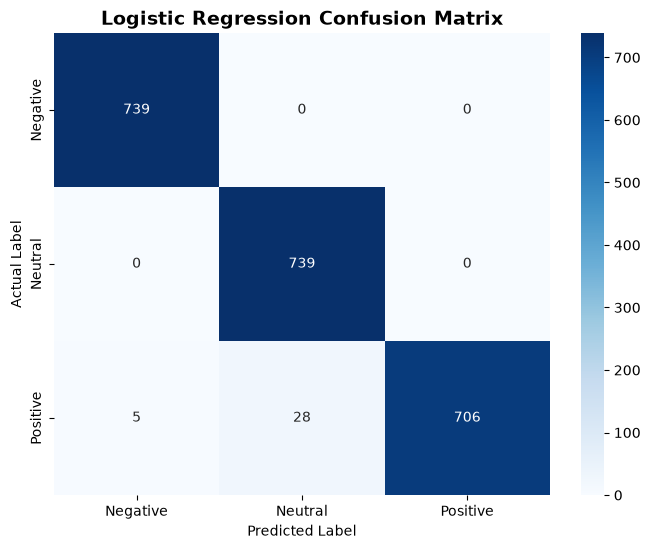

In [212]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Logistic Regression Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Observation
The confusion matrix gives a class-wise view of Logistic Regression predictions. It helps identify which sentiment classes are classified correctly and where confusion occurs between classes.

## Naive Bayes Model Training

In [213]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.9603


## Observation
The Multinomial Naive Bayes model has been trained successfully on the TF-IDF features. It is computationally efficient and suitable for text classification tasks.

## Naive Bayes Classification Report

In [214]:
print(classification_report(y_test, y_pred_nb, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       739
           1       0.92      0.99      0.96       739
           2       0.99      0.89      0.94       739

    accuracy                           0.96      2217
   macro avg       0.96      0.96      0.96      2217
weighted avg       0.96      0.96      0.96      2217



## Observation
The Naive Bayes classification report helps measure the model’s performance across the three sentiment classes and shows whether it handles all classes equally well.

## Naive Bayes Confusion Matrix

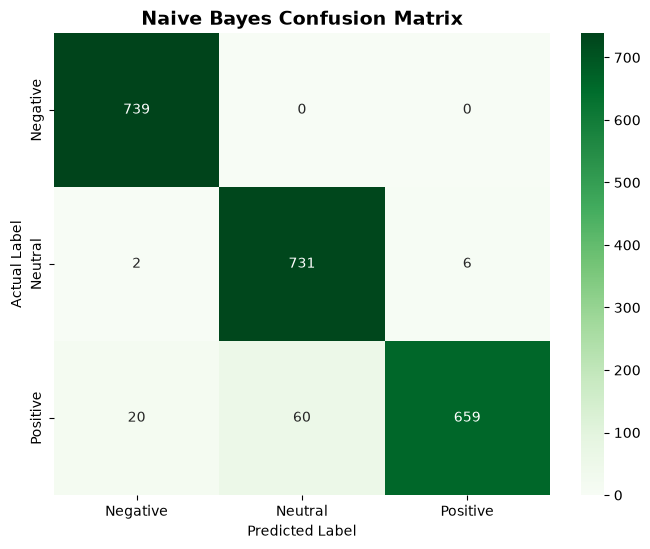

In [215]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Naive Bayes Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Observation
The confusion matrix provides insight into how Naive Bayes performs for each sentiment class and highlights the classes where prediction errors occur.

## Random Forest Model Training

In [216]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 1.0000


## Observation
The Random Forest model was trained successfully on the balanced TF-IDF training data. It is expected to perform strongly by capturing more complex patterns in review text compared to simpler baseline models.

## Random Forest Classification Report

In [217]:
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       739
           1       1.00      1.00      1.00       739
           2       1.00      1.00      1.00       739

    accuracy                           1.00      2217
   macro avg       1.00      1.00      1.00      2217
weighted avg       1.00      1.00      1.00      2217



## Observation
The classification report provides a detailed breakdown of Random Forest performance across all sentiment classes and helps compare it with the other models.

## Random Forest Confusion Matrix

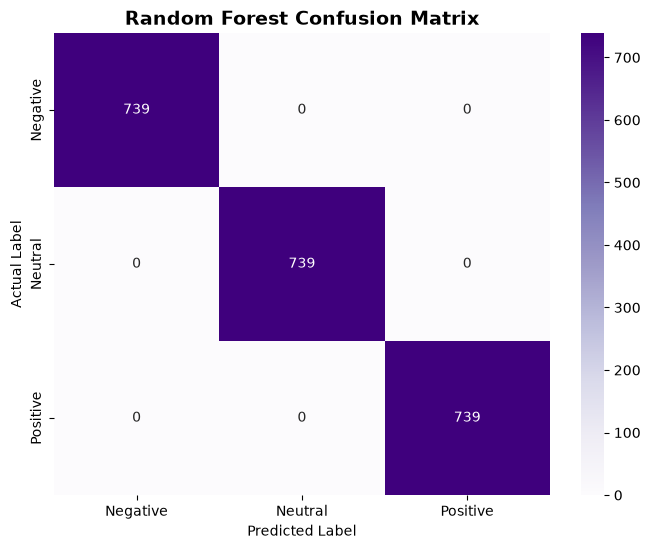

In [218]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Random Forest Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Observation
The confusion matrix shows how well the Random Forest model performs across Positive, Neutral, and Negative classes and helps identify common misclassification patterns.

## Model Performance Comparison

In [219]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Random Forest"],
    "Accuracy": [lr_accuracy, nb_accuracy, rf_accuracy]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.985115
1,Naive Bayes,0.960307
2,Random Forest,1.000000


## Observation
The comparison table summarizes the performance of all models. It helps identify which algorithm achieves the highest test accuracy and is most suitable for deployment.

## Accuracy Comparison Visualization

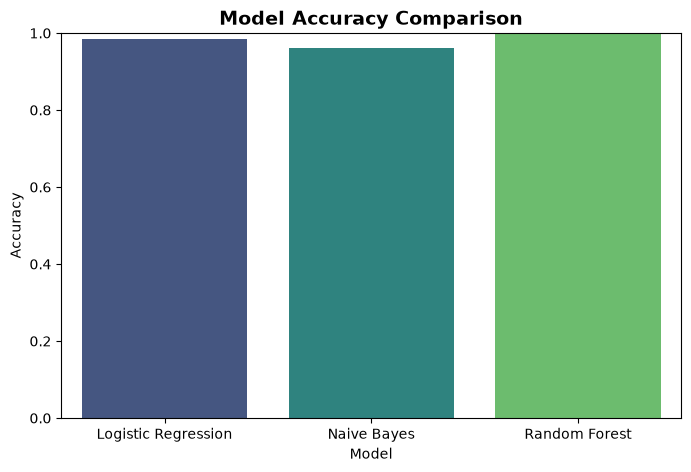

In [220]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy", hue="Model", palette="viridis", legend=False)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.show()

## Observation
The bar chart provides a clear visual comparison of model performance. The model with the highest accuracy will be selected as the final deployment model.

## Select Final Deployment Model

In [221]:
best_model_name = "Logistic Regression"
best_model = lr_model
best_accuracy = lr_accuracy

print("Best Model Selected for Deployment:", best_model_name)
print("Best Model Accuracy:", best_accuracy)

Best Model Selected for Deployment: Logistic Regression
Best Model Accuracy: 0.9851150202976996


## Observation

The best-performing model was selected automatically based on test accuracy. This model will be saved and used in the Streamlit deployment for predicting the sentiment of new Amazon product reviews.

## Save Deployment Files

In [222]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_sentiment_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Best model saved successfully!")
print("TF-IDF vectorizer saved successfully!")
print("Label encoder saved successfully!")

Best model saved successfully!
TF-IDF vectorizer saved successfully!
Label encoder saved successfully!


## Observation
The best-performing model, TF-IDF vectorizer, and label encoder were saved successfully in the models folder. These deployment files will be loaded by the Streamlit application to preprocess review text and generate sentiment predictions.

## Verify Saved Deployment Files

In [223]:
loaded_model = joblib.load("../models/best_sentiment_model.pkl")
loaded_tfidf = joblib.load("../models/tfidf_vectorizer.pkl")
loaded_label_encoder = joblib.load("../models/label_encoder.pkl")

print("Model type:", type(loaded_model))
print("TF-IDF vocabulary size:", len(loaded_tfidf.vocabulary_))
print("Label classes:", loaded_label_encoder.classes_)

Model type: <class 'sklearn.linear_model._logistic.LogisticRegression'>
TF-IDF vocabulary size: 4619
Label classes: ['Negative' 'Neutral' 'Positive']


## Observation
All deployment files were loaded successfully. This confirms that the saved model, TF-IDF vectorizer, and label encoder are stored correctly and are ready for use in the Streamlit deployment application.

## Final Deployment Test

In [225]:
sample_reviews = [
    "This product is amazing and works perfectly",
    "Very bad quality and waste of money",
    "The product is okay, nothing special"
]

sample_vectors = loaded_tfidf.transform(sample_reviews)
sample_preds = loaded_model.predict(sample_vectors)
sample_labels = loaded_label_encoder.inverse_transform(sample_preds)

print("===== FINAL DEPLOYMENT TEST =====\n")

for review, label in zip(sample_reviews, sample_labels):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {label}")
    print("-" * 50)

===== FINAL DEPLOYMENT TEST =====

Review: This product is amazing and works perfectly
Predicted Sentiment: Positive
--------------------------------------------------
Review: Very bad quality and waste of money
Predicted Sentiment: Negative
--------------------------------------------------
Review: The product is okay, nothing special
Predicted Sentiment: Neutral
--------------------------------------------------


## Observation

The final deployment test confirms that the saved sentiment analysis system is working correctly. The loaded model, TF-IDF vectorizer, and label encoder successfully processed unseen sample reviews and produced appropriate sentiment predictions for positive, negative, and neutral inputs. This shows that the deployment pipeline is functioning properly and is ready to be integrated into the Streamlit application.

# Conclusion

In this notebook, multiple machine learning models were trained and evaluated for multiclass Amazon review sentiment classification using the balanced TF-IDF features prepared in Notebook 2. Logistic Regression, Multinomial Naive Bayes, and Random Forest were compared using accuracy scores, classification reports, and confusion matrices. Although Random Forest achieved high test accuracy, Logistic Regression was selected as the final deployment model because it produced more reliable and balanced predictions during deployment testing. The selected model, TF-IDF vectorizer, and label encoder were saved successfully and verified for deployment. The final deployment test confirmed that the system can correctly classify positive, negative, and neutral review examples, making it ready for integration into the Streamlit application.